# Description

It explores the context/tissue/cell type of the top samples associated with an LV.

Follow the notebook instructions below.

# Modules

In [1]:
import re
from pathlib import Path

import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from data.recount2 import LVAnalysis
from utils import chunker
import conf

# Settings

Specify below the LV id you are interested in:

In [2]:
LV_NAME = "LV94"

# Paths

These are paths to folder and files where we'll save our figures.

In [3]:
OUTPUT_FIGURES_DIR = Path(conf.RESULTS_DIR, "demo", f"{LV_NAME.lower()}").resolve()
display(OUTPUT_FIGURES_DIR)
OUTPUT_FIGURES_DIR.mkdir(parents=True, exist_ok=True)

PosixPath('/opt/data/results/demo/lv94')

In [4]:
OUTPUT_CELL_TYPE_FILEPATH = OUTPUT_FIGURES_DIR / f"{LV_NAME.lower()}-cell_types.svg"
display(OUTPUT_CELL_TYPE_FILEPATH)

PosixPath('/opt/data/results/demo/lv94/lv94-cell_types.svg')

# Load MultiPLIER summary

In [5]:
multiplier_model_summary = pd.read_pickle(conf.MULTIPLIER["MODEL_SUMMARY_FILE"])

In [6]:
multiplier_model_summary.shape

(2157, 5)

In [7]:
multiplier_model_summary.head()

,pathway,LV index,AUC,p-value,FDR
1,KEGG_LYSINE_DEGRADATION,1,0.388059,0.866078,0.956005
2,REACTOME_MRNA_SPLICING,1,0.733057,0.000048,0.000582
3,MIPS_NOP56P_ASSOCIATED_PRE_RRNA_COMPLEX,1,0.680555,0.001628,0.011366
4,KEGG_DNA_REPLICATION,1,0.549473,0.312155,0.539951
5,PID_MYC_ACTIVPATHWAY,1,0.639303,0.021702,0.083739


# Load LV data

You can use the `LVAnalysis` class to explore an LV.

In [8]:
lv_obj = LVAnalysis(LV_NAME)

Here I show the top 20 genes for our LV. You can see gene symbols, the LV weight (in column `LV603`) and the cytoband.

In [9]:
lv_obj.lv_genes.head(20)

,gene_name,LV94,gene_band
0,AKAP12,5.296787,6q25.1
1,WNT16,4.882254,7q31.31
2,PDP1,4.402468,8q22.1
3,NTSR1,3.981409,20q13.33
4,MTAP,3.271176,9p21.3
5,AP1S3,3.127326,2q36.1
6,BMP4,3.109630,14q22.2
7,EZR,2.763310,6q25.3
8,CPOX,2.752332,3q11.2
9,GSTO2,2.423340,10q25.1


Show the pathways our LV is aligned to (neutrophils):

In [10]:
multiplier_model_summary[
    multiplier_model_summary["LV index"].isin((LV_NAME[2:],))
    & (
        (multiplier_model_summary["FDR"] < 0.05)
        & (multiplier_model_summary["AUC"] >= 0.75)
    )
]

[2025-09-24 15:19:27,645 - numexpr.utils] INFO: Note: NumExpr detected 32 cores but "NUMEXPR_MAX_THREADS" not set, so enforcing safe limit of 8.
[2025-09-24 15:19:27,646 - numexpr.utils] INFO: NumExpr defaulting to 8 threads.


,pathway,LV index,AUC,p-value,FDR


Here I load the LV metadata.
This is, for each sample from our matrix B, we load its metadata.
The `LVAnalysis` class takes care of downloading all necessary files from recount2.

In [11]:
lv_data = lv_obj.get_experiments_data()

SRP030617, SRP063339, SRP007506, SRP062230, SRP057437, SRP017435, SRP063980, SRP064323, SRP063978, SRP014320, SRP049510, SRP046741, SRP043273, SRP049436, SRP049823, SRP041753, SRP010064, SRP019810, SRP066895, SRP060227, SRP041162, SRP052713, SRP066424, SRP042402, SRP013288, SRP033057, SRP057196, SRP055569, SRP013985, SRP009269, SRP006309, SRP023270, SRP042937, SRP026537, SRP060416, SRP058773, SRP042161, SRP056912, SRP043960, SRP059035, SRP002184, SRP042184, 

/opt/code/libs/data/recount2.py:323: UserWarning: Not all experiments data could be loaded (41 != 42)
  warnings.warn(


In [12]:
lv_data.shape

(3424, 52)

In [13]:
lv_data.head()

cdna synthesis method library construction method  \
project   run                                                            
SRP030617 SRR1003755        Superscript RT        Nextera (transposon)   
          SRR1003756        Superscript RT        Nextera (transposon)   
          SRR1003757      Clontech SMARTer        Nextera (transposon)   
          SRR1003758      Clontech SMARTer        Nextera (transposon)   
          SRR1003759      Clontech SMARTer        Nextera (transposon)   

                     cell line clone time point passages treatment cell type  \
project   run                                                                  
SRP030617 SRR1003755    HCT116   NaN        NaN      NaN       NaN       NaN   
          SRR1003756    HCT116   NaN        NaN      NaN       NaN       NaN   
          SRR1003757    HCT116   NaN        NaN      NaN       NaN       NaN   
          SRR1003758    HCT116   NaN        NaN      NaN       NaN       NaN   
          SRR1003759    HCT116   NaN        NaN      NaN       NaN       NaN   

                     cell state transfected with  ... patient id compound  \
project   run                                     ...                       
SRP030617 SRR1003755        NaN              NaN  ...        NaN      NaN   
          SRR1003756        NaN              NaN  ...        NaN      NaN   
          SRR1003757        NaN              NaN  ...        NaN      NaN   
          SRR1003758        NaN              NaN  ...        NaN      NaN   
          SRR1003759        NaN              NaN  ...        NaN      NaN   

                     induction biological replicate  Sex Stage  \
project   run                                                    
SRP030617 SRR1003755       NaN                  NaN  NaN   NaN   
          SRR1003756       NaN                  NaN  NaN   NaN   
          SRR1003757       NaN                  NaN  NaN   NaN   
          SRR1003758       NaN                  NaN  NaN   NaN   
          SRR1003759       NaN                  NaN  NaN   NaN   

                     age at diagnosis final gtf2i mutation status  \
project   run                                                       
SRP030617 SRR1003755              NaN                         NaN   
          SRR1003756              NaN                         NaN   
          SRR1003757              NaN                         NaN   
          SRR1003758              NaN                         NaN   
          SRR1003759              NaN                         NaN   

                     who histotype      LV94  
project   run                                 
SRP030617 SRR1003755           NaN  0.878342  
          SRR1003756           NaN  0.867322  
          SRR1003757           NaN  0.787905  
          SRR1003758           NaN  0.752513  
          SRR1003759           NaN  0.765556  

[5 rows x 52 columns]

# LV cell types analysis

## Get top attributes

Here I quickly show the top attributes in our metadata for which we have the largest LV variance.
This is just to have an idea of the variance across different attributes

In [14]:
lv_attrs = lv_obj.get_attributes_variation_score()
display(lv_attrs.head(20))

cell state                     0.190304
time point                     0.155037
cell line                      0.103869
treatment                      0.091665
clone                          0.089258
dsn time                       0.067580
infected with                  0.062981
genotype/variation             0.043016
serum                          0.041199
strain                         0.041199
treated with                   0.033441
cdna synthesis method          0.031171
library construction method    0.031171
tissue                         0.015732
shRNA                          0.015725
biological replicate           0.015213
cell type                      0.014400
genotype                       0.012599
molecule subtype               0.011722
dna-damage                     0.011705
dtype: float64

Since we are interested in cell types and tissues, the code below will find which attributes contain "cell type" or "tissue", so we can select from these results.

In [15]:
# show those with cell type or tissue in their name
_tmp = pd.Series(lv_attrs.index)
lv_attrs[
    _tmp.str.match(
        "(?:cell.*(type|line)$)|(?:tissue$)|(?:tissue.*type$)",
        case=False,
        flags=re.IGNORECASE,
    ).values
].sort_values(ascending=False)

cell line     0.103869
tissue        0.015732
cell type     0.014400
celll line    0.003754
dtype: float64

Select from the output above those you are interested in. Usually all of them.

In [16]:
lv_attrs_selected = [
    "cell line",
    "tissue",
    "cell type",
    "celll line",
]

In [17]:
_tmp = lv_data.loc[
    :,
    lv_attrs_selected + [LV_NAME],
]

In [18]:
_tmp_seq = list(chunker(_tmp.sort_values(LV_NAME, ascending=False), 25))

Now that we selected attributes that might be providing information about the cell type, we can see which are the top ones.

If you change the number in the cell below, you can paginate over the entire set of results; for example, with `_tmp_seq[1]` you'll see the next "page" in a descending order with respect to the LV value. So the ones at the top are the most important ones.

In [19]:
_tmp_seq[0]

cell line tissue                       cell type  \
project   run                                                           
SRP030617 SRR1003789    HCT116    NaN                             NaN   
          SRR1003784    HCT116    NaN                             NaN   
SRP063339 SRR2242938    HCT116    NaN                             NaN   
SRP030617 SRR1003796    HCT116    NaN                             NaN   
SRP007506 SRR314740    HCT-116    NaN                             NaN   
SRP063339 SRR2242932    HCT116    NaN                             NaN   
SRP007506 SRR314741    HCT-116    NaN                             NaN   
SRP030617 SRR1003795    HCT116    NaN                             NaN   
SRP062230 SRR2153524    HCT116    NaN                 colon carcinoma   
SRP007506 SRR314739    HCT-116    NaN                             NaN   
SRP063339 SRR2242926    HCT116    NaN                             NaN   
SRP030617 SRR1003755    HCT116    NaN                             NaN   
SRP063339 SRR2242923    HCT116    NaN                             NaN   
SRP007506 SRR314738    HCT-116    NaN                             NaN   
SRP030617 SRR1003756    HCT116    NaN                             NaN   
SRP062230 SRR2153523    HCT116    NaN                 colon carcinoma   
SRP057437 SRR1981008   HCT 116    NaN  Colorectal carcinoma cell line   
          SRR1981012   HCT 116    NaN  Colorectal carcinoma cell line   
SRP030617 SRR1003836    HCT116    NaN                             NaN   
SRP057437 SRR1981011   HCT 116    NaN  Colorectal carcinoma cell line   
SRP017435 SRR628736    HCT-116    NaN                             NaN   
SRP030617 SRR1003808    HCT116    NaN                             NaN   
          SRR1003820    HCT116    NaN                             NaN   
SRP017435 SRR628737    HCT-116    NaN                             NaN   
SRP057437 SRR1981007   HCT 116    NaN  Colorectal carcinoma cell line   

                     celll line      LV94  
project   run                              
SRP030617 SRR1003789        NaN  1.211251  
          SRR1003784        NaN  1.046152  
SRP063339 SRR2242938        NaN  1.031260  
SRP030617 SRR1003796        NaN  0.921076  
SRP007506 SRR314740         NaN  0.917849  
SRP063339 SRR2242932        NaN  0.911211  
SRP007506 SRR314741         NaN  0.910415  
SRP030617 SRR1003795        NaN  0.905705  
SRP062230 SRR2153524        NaN  0.899509  
SRP007506 SRR314739         NaN  0.881594  
SRP063339 SRR2242926        NaN  0.879392  
SRP030617 SRR1003755        NaN  0.878342  
SRP063339 SRR2242923        NaN  0.874801  
SRP007506 SRR314738         NaN  0.870860  
SRP030617 SRR1003756        NaN  0.867322  
SRP062230 SRR2153523        NaN  0.858625  
SRP057437 SRR1981008        NaN  0.856282  
          SRR1981012        NaN  0.855181  
SRP030617 SRR1003836        NaN  0.853932  
SRP057437 SRR1981011        NaN  0.848078  
SRP017435 SRR628736         NaN  0.847217  
SRP030617 SRR1003808        NaN  0.834306  
          SRR1003820        NaN  0.832185  
SRP017435 SRR628737         NaN  0.829082  
SRP057437 SRR1981007        NaN  0.828503

You can see above that the RNA-seq samples are from neutrophils or granulocytes.
If we move to the next "page", we'll see this:

In [20]:
_tmp_seq[1]

tissue subtype                               tissue  \
project   run                                                              
SRP050499 SRR2013759            NaN                                  NaN   
SRP066834 SRR2967826            NaN                      Fetal neocortex   
SRP050499 SRR2013685            NaN                                  NaN   
SRP060416 SRR2088422            NaN                                  NaN   
SRP061801 SRR2134571            NaN                                  NaN   
SRP055513 SRR1818587            NaN                                  eye   
          SRR1818567            NaN                              chorion   
SRP058773 SRR2042655            NaN                                  NaN   
SRP013402 SRR500984             NaN                                  NaN   
SRP066834 SRR2967255            NaN  Dissociated whole cerebral organoid   
SRP059775 SRR2074917            NaN                                  NaN   
SRP041179 SRR1238524            NaN                                  NaN   
          SRR1238523            NaN                                  NaN   
SRP042161 SRR1295011            NaN                                  NaN   
SRP019994 SRR797076             NaN                          Soft Tissue   
SRP041179 SRR1238526            NaN                                  NaN   
SRP066834 SRR2967310            NaN  Dissociated whole cerebral organoid   
SRP053195 SRR1787911            NaN                                  NaN   
SRP041179 SRR1238525            NaN                                  NaN   
          SRR1238501            NaN                                  NaN   
SRP007596 SRR317199             NaN                                  NaN   
SRP019994 SRR797123             NaN                          Soft Tissue   
SRP050499 SRR2013737            NaN                                  NaN   
SRP066834 SRR2967249            NaN  Dissociated whole cerebral organoid   
SRP036821 SRR1163262          DDLPS                  soft tissue sarcoma   

                                         cell type  \
project   run                                        
SRP050499 SRR2013759                           NaN   
SRP066834 SRR2967826                           NaN   
SRP050499 SRR2013685                           NaN   
SRP060416 SRR2088422  tonsil Innate lymphoid cells   
SRP061801 SRR2134571                           NaN   
SRP055513 SRR1818587                           NaN   
          SRR1818567                           NaN   
SRP058773 SRR2042655                           NaN   
SRP013402 SRR500984               Human fibroblast   
SRP066834 SRR2967255                           NaN   
SRP059775 SRR2074917                           NaN   
SRP041179 SRR1238524                  hESC (WA-09)   
          SRR1238523                  hESC (WA-09)   
SRP042161 SRR1295011                  Glioblastoma   
SRP019994 SRR797076                            NaN   
SRP041179 SRR1238526                  hESC (WA-09)   
SRP066834 SRR2967310                           NaN   
SRP053195 SRR1787911                           NaN   
SRP041179 SRR1238525                  hESC (WA-09)   
          SRR1238501                  hESC (WA-09)   
SRP007596 SRR317199         osteosarcoma cell line   
SRP019994 SRR797123                            NaN   
SRP050499 SRR2013737                           NaN   
SRP066834 SRR2967249                           NaN   
SRP036821 SRR1163262                           NaN   

                                         cell type cell line/type     LV918  
project   run                                                                
SRP050499 SRR2013759                           NaN            NaN  0.449913  
SRP066834 SRR2967826                           NaN            NaN  0.449686  
SRP050499 SRR2013685                           NaN            NaN  0.432231  
SRP060416 SRR2088422  tonsil Innate lymphoid cells            NaN  0.431176  
SRP061801 SRR2134571                     

Although the attributes we selected (`cell type`, `celltype` and `tissue`) seem to be enough for most of the RNA-seq samples to get their cell types, this is not the case for some of them. For example, we have empty values (NaN) for `SRP015360`.

You can explore the metadata provided for a particular SPR with the code below. Let's see what we have in `SRP015360`:

In [21]:
# list the top 10 samples from this project
lv_data.loc[["SRP039591"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(10)

KeyError: "['SRP039591'] not in index"

So for `SRP015360` we only have three attributes: `age`, `Sex` and `treatment`. No cell type information. Here you can start grasping the challenges in analyzing this data.

If you are really interested in this metadata for this project, you can use this URL:
```
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP015360
```
where you can put the SRP code you want. If you check the URL above, you'll see that these samples were taken from neutrophils as well (treated with different stimuli), although we don't have metadata about the cell type/tissue.

Ok, we do not want several attributes conveying the same information (cell types), just a single one, so here we'll combine the attributes we found before with a particular _order_.
In this case I select `cell type` _first_ (the order is important), `celltype` as second, and `tissue` as third/last.
This means that I will use the information in `cell type` first, but if this is empty (as in `SRP045500`), we'll try with `celltype`, and so on.

In [20]:
SELECTED_ATTRIBUTES = [
    "cell line",
    "tissue",
    "cell type",
    "celll line",
]

## Get a single attribute with "cell type/tissue" information

In [21]:
plot_data = lv_data.loc[:, SELECTED_ATTRIBUTES + [LV_NAME]]

In [22]:
# if blank/nan, fill cell type column with tissue content
_new_column = plot_data[SELECTED_ATTRIBUTES].fillna(method="backfill", axis=1)[
    SELECTED_ATTRIBUTES[0]
]
plot_data[SELECTED_ATTRIBUTES[0]] = _new_column
plot_data = plot_data.drop(columns=SELECTED_ATTRIBUTES[1:])
plot_data = plot_data.fillna({SELECTED_ATTRIBUTES[0]: "NOT CATEGORIZED"})

In [23]:
plot_data = plot_data.sort_values(LV_NAME, ascending=False)

In [24]:
plot_data.head(20)

cell line      LV94
project   run                           
SRP030617 SRR1003789    HCT116  1.211251
          SRR1003784    HCT116  1.046152
SRP063339 SRR2242938    HCT116  1.031260
SRP030617 SRR1003796    HCT116  0.921076
SRP007506 SRR314740    HCT-116  0.917849
SRP063339 SRR2242932    HCT116  0.911211
SRP007506 SRR314741    HCT-116  0.910415
SRP030617 SRR1003795    HCT116  0.905705
SRP062230 SRR2153524    HCT116  0.899509
SRP007506 SRR314739    HCT-116  0.881594
SRP063339 SRR2242926    HCT116  0.879392
SRP030617 SRR1003755    HCT116  0.878342
SRP063339 SRR2242923    HCT116  0.874801
SRP007506 SRR314738    HCT-116  0.870860
SRP030617 SRR1003756    HCT116  0.867322
SRP062230 SRR2153523    HCT116  0.858625
SRP057437 SRR1981008   HCT 116  0.856282
          SRR1981012   HCT 116  0.855181
SRP030617 SRR1003836    HCT116  0.853932
SRP057437 SRR1981011   HCT 116  0.848078

You can see that now all attributes ("celltype", "cell type" and "tissue") are combined under a single attribute named "cell type".
For example, if you look at `SRP045500`, which had a value under "celltype" but an empty (NaN) value for attribute "cell type", that now the value was moved to "cell type" (it was unified into this single attribute).

If you see "NOT CATEGORIZED", it means that none of the attributes you used had a value (they were all empty or NaN). In this case you would go the URL before and read the article/RNA-seq data description to find out the cell type or tissue (or whatever attribute your are interested in).

## Standardize cell type names

When cell type values are different but represent the same cell type, we unify them:

In [25]:
final_plot_data = plot_data.replace(
    {
        SELECTED_ATTRIBUTES[0]: {
            # # neutrophils:
            # "primary human neutrophils": "Neutrophils",
            # "Neutrophil isolated from peripheral blood": "Neutrophils",
            # "Neutrophil": "Neutrophils",
            # "neutrophils (Neu)": "Neutrophils",
            # # granulocytes:
            # "granulocyte": "Granulocytes",
            # # monocytes:
            # "primary human monocytes": "Monocytes",
            # # whole blood:
            # #             "whole blood": "Whole blood",  # uncomment this line to merge occurences of "whole blood" into "Whole blood"
            # "Whole Blood": "Whole blood",
            # # PBMC:
            # "primary human PBMC": "PBMC",
            # # B-cells:
            # "primary human B cells": "B cells",
            # # T-cells:
            # "primary human T cells": "T cells",
            # # epithelial cells:
            # "epithelial cells (Epi)": "Epithelial cells",
            # "primary human myeloid DC": "mDCs",
        }
    }
)

The code below is more advanced, but you can use it to customize even further your final attribute value (for example, if you want to use the cell type, but put the treatment name with parenthesis).

In [26]:
# # add also tissue information to these projects
# _srp_code = "SRP061881"
# _tmp = final_plot_data.loc[(_srp_code,)].apply(
#     lambda x: lv_data.loc[(_srp_code, x.name), "cell type"]
#     + f" ({lv_data.loc[(_srp_code, x.name), 'tissue']})",
#     axis=1,
# )
# final_plot_data.loc[(_srp_code, _tmp.index), SELECTED_ATTRIBUTES[0]] = _tmp.values

In [27]:
# # all samples from SRP015360 are neutrophils
# final_plot_data[SELECTED_ATTRIBUTES[0]] = final_plot_data.apply(
#     lambda x: "Neutrophils" if x.name[0] in ("SRP015360",) else x[SELECTED_ATTRIBUTES[0]],
#     axis=1,
# )

In [28]:
final_plot_data = final_plot_data.sort_values(LV_NAME, ascending=False)

## Threshold LV values

The code below is useful in case you want to put a threshold to the plot (for example, you have same samples with very high values).

In [29]:
# final_plot_data.loc[
#     final_plot_data[LV_NAME] > LV_AXIS_THRESHOLD, LV_NAME
# ] = LV_AXIS_THRESHOLD

## Delete samples with no tissue/cell type information

If you are not interested in samples for which we couldn't find cell type/tissue information, you can delete them by uncommenting the code below.
However, if you want, you can take a look at those later (we'll show you how at the end).

In [30]:
# final_plot_data = final_plot_data[
#     final_plot_data[SELECTED_ATTRIBUTE] != "NOT CATEGORIZED"
# ]

## Set top cell types to show

In [31]:
N_TOP_ATTRS = 10

In [32]:
attr_order = (
    final_plot_data.groupby(SELECTED_ATTRIBUTES[0])
    .max()
    .sort_values(LV_NAME, ascending=False)
    .index[:N_TOP_ATTRS]
    .tolist()
)

In [33]:
len(attr_order)

10

In [34]:
attr_order[:5]

['HCT116',
 'HCT-116',
 'HCT 116',
 'human colon cancer cell',
 'vorinostat-resistant HCT116']

# Plot

Now we create the plot with RNA-seq samples as points, cell types in the x-axis, and the LV value in the y-axis.
This shows you in which cell types genes in LV603 are primirily expressed.

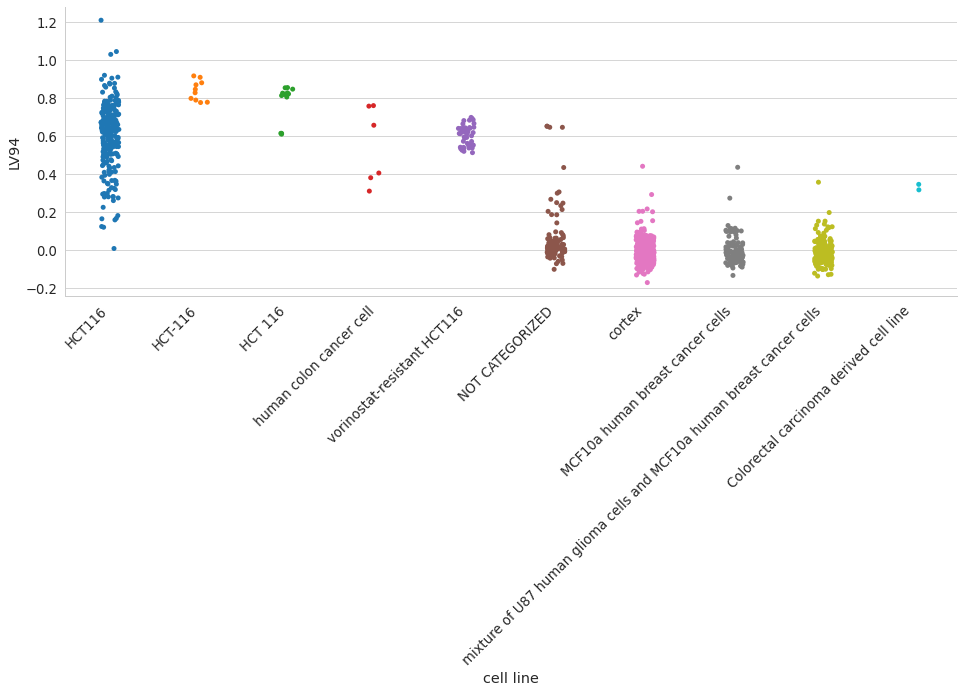

In [35]:
with sns.plotting_context("paper", font_scale=1.5), sns.axes_style("whitegrid"):
    sns.catplot(
        data=final_plot_data,
        y=LV_NAME,
        x=SELECTED_ATTRIBUTES[0],
        order=attr_order,
        kind="strip",
        height=5,
        aspect=3,
    )
    plt.xticks(rotation=45, horizontalalignment="right")

    # You can save the figure if you uncomment the code below
    # the figure will be created under ${DATA_FOLDER}/results/demo

    plt.savefig(
        OUTPUT_CELL_TYPE_FILEPATH,
        bbox_inches="tight",
        facecolor="white",
    )

# Debug

Now that you have the figure for your LV, you can debug some things.
For example, you'll see above that some samples are "NOT CATEGORIZED".
Let's see which are those:

In [36]:
with pd.option_context(
    "display.max_rows", None, "display.max_columns", None, "display.max_colwidth", None
):
    _tmp = final_plot_data[
        final_plot_data[SELECTED_ATTRIBUTES[0]].str.contains("HCT")
    ]
    display(_tmp.head(20))

cell line      LV94
project   run                           
SRP030617 SRR1003789    HCT116  1.211251
          SRR1003784    HCT116  1.046152
SRP063339 SRR2242938    HCT116  1.031260
SRP030617 SRR1003796    HCT116  0.921076
SRP007506 SRR314740    HCT-116  0.917849
SRP063339 SRR2242932    HCT116  0.911211
SRP007506 SRR314741    HCT-116  0.910415
SRP030617 SRR1003795    HCT116  0.905705
SRP062230 SRR2153524    HCT116  0.899509
SRP007506 SRR314739    HCT-116  0.881594
SRP063339 SRR2242926    HCT116  0.879392
SRP030617 SRR1003755    HCT116  0.878342
SRP063339 SRR2242923    HCT116  0.874801
SRP007506 SRR314738    HCT-116  0.870860
SRP030617 SRR1003756    HCT116  0.867322
SRP062230 SRR2153523    HCT116  0.858625
SRP057437 SRR1981008   HCT 116  0.856282
          SRR1981012   HCT 116  0.855181
SRP030617 SRR1003836    HCT116  0.853932
SRP057437 SRR1981011   HCT 116  0.848078

We don't have information about cell type/tissue for these.
But we can manually go to the URL showed before and check out.
For example, for `SRP015360` we can open our browser with this URL:
https://trace.ncbi.nlm.nih.gov/Traces/sra/?study=SRP057205, and see that the samples were taken from neutrophils.

If you need to see which information is provided by each SRP, you can again use the code below:

In [39]:
# what is there in these projects?
lv_data.loc[["SRP063339"]].dropna(how="all", axis=1).sort_values(
    LV_NAME, ascending=False
).head(60)

cell line                    clone  \
project   run                                             
SRP063339 SRR2242938    HCT116   18qNE Deletion Clone 1   
          SRR2242932    HCT116        E7 Deletion Clone   
          SRR2242926    HCT116           Control Cone 3   
          SRR2242923    HCT116          Control Clone 2   
          SRR2242929    HCT116          Control Clone 4   
          SRR2242934    HCT116        E7 Deletion Clone   
          SRR2242920    HCT116          Control Clone 1   
          SRR2242933    HCT116        E7 Deletion Clone   
          SRR2242940    HCT116   18qNE Deletion Clone 3   
          SRR2242939    HCT116   18qNE Deletion Clone 2   
          SRR2242928    HCT116           Control Cone 3   
          SRR2242930    HCT116          Control Clone 4   
          SRR2242931    HCT116          Control Clone 4   
          SRR2242925    HCT116          Control Clone 2   
          SRR2242921    HCT116          Control Clone 1   
          SRR2242922    HCT116          Control Clone 1   
          SRR2242944    HCT116    18qE Deletion Clone 2   
          SRR2242943    HCT116    18qE Deletion Clone 1   
          SRR2242924    HCT116          Control Clone 2   
          SRR2242941    HCT116          Control Clone 1   
          SRR2242927    HCT116           Control Cone 3   
          SRR2242942    HCT116          Control Conle 2   
          SRR2242947    HEK293  HEK293 Deletion Clone 1   
          SRR2242948    HEK293  HEK293 Deletion Clone 1   
          SRR2242945    HEK293   HEK293 Control Clone 1   
          SRR2242946    HEK293   HEK293 Control Clone 2   

                                  time point      LV94  
project   run                                           
SRP063339 SRR2242938  RNA extracted on day A  1.031260  
          SRR2242932  RNA extracted on day A  0.911211  
          SRR2242926  RNA extracted on day A  0.879392  
          SRR2242923  RNA extracted on day A  0.874801  
          SRR2242929  RNA extracted on day A  0.825395  
          SRR2242934  RNA extracted on day C  0.788623  
          SRR2242920  RNA extracted on day A  0.780620  
          SRR2242933  RNA extracted on day B  0.752707  
          SRR2242940  RNA extracted on day A  0.750509  
          SRR2242939  RNA extracted on day B  0.744037  
          SRR2242928  RNA extracted on day C  0.741833  
          SRR2242930  RNA extracted on day B  0.733982  
          SRR2242931  RNA extracted on day C  0.727599  
          SRR2242925  RNA extracted on day C  0.725582  
          SRR2242921  RNA extracted on day B  0.722573  
          SRR2242922  RNA extracted on day C  0.720534  
          SRR2242944  RNA extracted on day D  0.713727  
          SRR2242943  RNA extracted on day D  0.707055  
          SRR2242924  RNA extracted on day B  0.703623  
          SRR2242941  RNA extracted on day D  0.695928  
          SRR2242927  RNA extracted on day B  0.680938  
          SRR2242942  RNA extracted on day D  0.671486  
          SRR2242947  RNA extracted on day E -0.006264  
          SRR2242948  RNA extracted on day E -0.008022  
          SRR2242945  RNA extracted on day E -0.011703  
          SRR2242946  RNA extracted on day E -0.032402

Now you can go back to section `Standardize cell type names` in this notebook and adjust according to this findings to improve the figure.
Once you are happy, you can remove the `NOT CATEGORIZED` items by uncommenting the code in `Delete samples with no tissue/cell type information`.